# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/toBESkiii/FlyRank_AI_Intership/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*


SEO and content teams may manage thousands of pages, making it costly to manually inspect every page for possible refresh or optimisation opportunities.

My capstone focuses on **Refresh / Content Opportunity Scoring**: prioritising which content pages an SEO specialist or content editor should investigate first.

### Research question

**Can observable page-level search-performance and freshness signals be used to rank content pages for human review more effectively than a simple rule-based baseline?**

The decision supported by this work is:

**Which pages should a content or SEO specialist review first when deciding where limited editorial attention may be most useful?**

The system produces a ranked review queue rather than an automatic editorial decision. Higher-ranked pages are investigated first, while a human reviewer decides whether the appropriate outcome is a refresh, title/snippet review, content expansion, monitoring, further investigation, or no action.

The analysis uses an observed decline proxy to evaluate ranking quality. Therefore, the work should be interpreted as **measured decision-support for prioritisation**, not as proof that a page will decline in the future or that a particular content change will improve performance.


In [ ]:
# ---------------------------------------------------------
# Capstone research framing
# ---------------------------------------------------------

capstone_lane = "Refresh / Content Opportunity Scoring"

research_question = (
    "Can observable page-level search-performance and freshness "
    "signals be used to rank content pages for human review more "
    "effectively than a simple rule-based baseline?"
)

decision_supported = (
    "Which pages should an SEO specialist or content editor "
    "investigate first?"
)

system_output = "Ranked human-review queue"

automation_boundary = (
    "Decision-support only; no automatic refresh, deletion, "
    "rewriting or publishing."
)

print("Lane:")
print(capstone_lane)

print("\nResearch question:")
print(research_question)

print("\nDecision supported:")
print(decision_supported)

print("\nSystem output:")
print(system_output)

print("\nAutomation boundary:")
print(automation_boundary)

Lane:
Refresh / Content Opportunity Scoring

Research question:
Can observable page-level search-performance and freshness signals be used to rank content pages for human review more effectively than a simple rule-based baseline?

Decision supported:
Which pages should an SEO specialist or content editor investigate first?

System output:
Ranked human-review queue

Automation boundary:
Decision-support only; no automatic refresh, deletion, rewriting or publishing.


## 2. Data

## 2. Data

### Data release

This project uses the FlyRank pseudonymised internship data release, build `flyrank_pseudonymized_warehouse_release_v20260703`.

The full warehouse release contains several related tables. The largest is `fact_content_daily_performance`, containing 78,835,655 daily page-performance records. The release also contains client and content dimension tables and a 90-day query-level fact table.

The daily warehouse covers reporting dates from 27 January 2025 through 30 June 2026.

### Warehouse investigation

During the data-contract stage, I used the warehouse to understand the available data, row grain, time coverage and measurement limitations before modelling.

The primary warehouse table inspected was:

`fact_content_daily_performance`

Its grain is:

**report date × pseudonymised client × pseudonymised content item**

I used March 2026 as a development month for these checks rather than repeatedly querying the entire warehouse.

One important finding was that GA4 availability was limited in the March development data. Only 413,966 of 9,841,378 rows had `ga4_data_available IS TRUE`, approximately 4.21%. I therefore avoided treating zero-filled or unavailable analytics fields as evidence of zero engagement.

### Modelling dataset

The final Refresh / Content Opportunity models in this paper were trained and evaluated on:

`data/raw/content_refresh_anonymized.csv`

This is a **30,000-page × 44-column anonymised starter dataset covering 32 pseudonymised clients**.

Each row represents one content page, with search, content, keyword and engagement measurements aggregated over a trailing 90-day observation window.

This distinction is important: although the internship warehouse provides approximately 79 million daily records for broader investigation, the Random Forest results reported in this paper were measured on the 30,000-page modelling slice. They should not be interpreted as results from training on the entire warehouse.

### Data used for modelling

Five observable features were retained for the final Week-5 model:

* `days_since_last_update`
* `impressions_90d`
* `ctr`
* `avg_position`
* `search_volume`

The temporary evaluation target was derived as:

`decline_proxy = 1` when `trend_direction == "down"`, otherwise `0`.

This is an observed proxy based on recent performance rather than a clean future outcome.

### Exclusions

I excluded the following from model inputs:

* `trend_direction`
* `trend_pct`
* `decline_proxy`
* `client_id`
* `content_id`

`trend_direction` and `trend_pct` were excluded because they directly define or contribute to the proxy target and would create target leakage.

`client_id` and `content_id` were retained only for grouping, splitting and review. They were not used as predictive features.

Raw client names, domains, URLs and private search queries were not used in this analysis. The released data uses pseudonymised identifiers so the public paper can discuss patterns without exposing client-specific information.

### Public-safe scope

The paper reports aggregated measurements, pseudonymised identifiers and model-level results only. It does not attempt to recover the identity of any client, URL, keyword or query represented in the data.


In [ ]:
import pandas as pd

# ---------------------------------------------------------
# 1. Load the modelling dataset used by the capstone model
# ---------------------------------------------------------

DATA_URL = (
    "https://raw.githubusercontent.com/"
    "toBESkiii/FlyRank_AI_Intership/main/"
    "data/raw/content_refresh_anonymized.csv"
)

page_dataset = pd.read_csv(DATA_URL)

# Recreate the observed evaluation proxy
page_dataset["decline_proxy"] = (
    page_dataset["trend_direction"] == "down"
).astype(int)


# ---------------------------------------------------------
# 2. Summarise the actual modelling dataset
# ---------------------------------------------------------

modelling_data_summary = pd.DataFrame(
    {
        "Item": [
            "Pages",
            "Original columns",
            "Pseudonymised clients",
            "Declining-proxy pages",
            "Decline-proxy rate"
        ],
        "Value": [
            len(page_dataset),
            page_dataset.shape[1] - 1,
            page_dataset["client_id"].nunique(),
            int(page_dataset["decline_proxy"].sum()),
            round(
                page_dataset["decline_proxy"].mean(),
                3
            )
        ]
    }
)

print("MODELLING DATASET")
display(modelling_data_summary)


# ---------------------------------------------------------
# 3. Warehouse release context
# ---------------------------------------------------------

warehouse_release_summary = pd.DataFrame(
    {
        "Table": [
            "dim_clients",
            "dim_content",
            "fact_content_daily_performance",
            "fact_content_query_90d"
        ],
        "Rows": [
            104,
            519606,
            78835655,
            2414248
        ],
        "Grain": [
            "one row per pseudonymised client",
            "one row per pseudonymised content item",
            "date × client × content",
            "client × content × query hash"
        ]
    }
)

print("\nWAREHOUSE RELEASE CONTEXT")
display(warehouse_release_summary)


# ---------------------------------------------------------
# 4. Evidence from the Week-3 warehouse data-contract audit
# ---------------------------------------------------------

warehouse_audit_summary = pd.DataFrame(
    {
        "Check": [
            "Development month",
            "March daily-fact rows",
            "Rows with confirmed GA4 availability",
            "GA4 availability percentage"
        ],
        "Result": [
            "March 2026",
            9841378,
            413966,
            "4.21%"
        ],
        "Evidence source": [
            "w03_data_contract.ipynb",
            "w03_data_contract.ipynb",
            "w03_data_contract.ipynb",
            "w03_data_contract.ipynb"
        ]
    }
)

print("\nWAREHOUSE AUDIT RECEIPT")
display(warehouse_audit_summary)


# ---------------------------------------------------------
# 5. Public-safety / leakage exclusions
# ---------------------------------------------------------

model_features = [
    "days_since_last_update",
    "impressions_90d",
    "ctr",
    "avg_position",
    "search_volume"
]

excluded_from_model = [
    "trend_direction",
    "trend_pct",
    "decline_proxy",
    "client_id",
    "content_id"
]

print("\nModel features:")
print(model_features)

print("\nExplicitly excluded from model inputs:")
print(excluded_from_model)

MODELLING DATASET


,Item,Value
0,Pages,30000.000
1,Original columns,44.000
2,Pseudonymised clients,32.000
3,Declining-proxy pages,16262.000
4,Decline-proxy rate,0.542



WAREHOUSE RELEASE CONTEXT


,Table,Rows,Grain
0,dim_clients,104,one row per pseudonymised client
1,dim_content,519606,one row per pseudonymised content item
2,fact_content_daily_performance,78835655,date × client × content
3,fact_content_query_90d,2414248,client × content × query hash



WAREHOUSE AUDIT RECEIPT


,Check,Result,Evidence source
0,Development month,March 2026,w03_data_contract.ipynb
1,March daily-fact rows,9841378,w03_data_contract.ipynb
2,Rows with confirmed GA4 availability,413966,w03_data_contract.ipynb
3,GA4 availability percentage,4.21%,w03_data_contract.ipynb



Model features:
['days_since_last_update', 'impressions_90d', 'ctr', 'avg_position', 'search_volume']

Explicitly excluded from model inputs:
['trend_direction', 'trend_pct', 'decline_proxy', 'client_id', 'content_id']


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Problem formulation

The capstone is treated primarily as a **ranking and prioritisation problem**.

The operational goal is not simply to classify every page as declining or not declining. Instead, each method produces a score that allows pages to be ordered from highest to lowest review priority.

### Evaluation proxy

The temporary evaluation target is:

`decline_proxy = 1` when `trend_direction == "down"`, otherwise `0`.

This target represents an observed recent decline state. It is not a clean future outcome, so the model is evaluated as a decision-support ranking system rather than as a proven future-decline predictor.

### Model features

The final models use five observable page-level signals:

* `days_since_last_update`
* `impressions_90d`
* `ctr`
* `avg_position`
* `search_volume`

`avg_position = 0` is treated as missing rather than as a genuine search rank.

Missing numerical values are imputed using the median learned from the training data.

Logistic Regression additionally uses feature standardisation because its optimisation is sensitive to features operating on very different numerical scales.

### Baseline

Before training machine-learning models, I created a transparent Week-4 baseline.

A page qualifies for review when:

* `days_since_last_update >= 90`, and
* `impressions_90d >= 300`.

For qualifying pages, `impressions_90d` becomes the ranking score.

This baseline represents a simple **stale-but-visible** rule that a human analyst could understand and reproduce without machine learning.

### Models

Two machine-learning approaches were compared:

1. **Logistic Regression** — selected as a simple and interpretable probabilistic classifier.
2. **Random Forest** — selected as a more flexible model capable of learning non-linear relationships and interactions between page signals.

For both models, the probability assigned to `decline_proxy = 1` is used as the ranking score.

The purpose of using Random Forest was not to reward complexity. It was retained only because it produced stronger measured ranking performance than both Logistic Regression and the rule-based baseline.

### Validation design

The primary evaluation uses a **grouped client-level holdout**.

Pages from the same `client_id` are kept entirely within either the training set or the test set. This prevents pages belonging to the same client from appearing on both sides of the split.

The final grouped split contained:

* 23,837 training pages
* 6,163 test pages
* zero clients shared between train and test

This design provides a stronger test of whether the model can rank pages belonging to clients that were not observed during training.

### Evaluation metrics

The primary metrics are:

* **Precision@10** — the proportion of decline-proxy pages among the ten highest-ranked recommendations.
* **Precision@50** — the proportion of decline-proxy pages among the fifty highest-ranked recommendations.

These metrics were chosen because the practical value of the system is concentrated near the top of the review queue.

### Leakage audit

The following columns are explicitly excluded from model inputs:

* `trend_direction`
* `trend_pct`
* `decline_proxy`
* `client_id`
* `content_id`

`trend_direction` and `trend_pct` are excluded because they directly define or contribute to the proxy target.

Identifiers are used only for grouping, splitting and review.

A further temporal limitation remains: recent search-performance features such as impressions, CTR and average position may overlap with the period used to construct the observed decline proxy. For this reason, the reported results are interpreted as **observed, directional decision-support performance**, not as evidence of future causal prediction.


In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import numpy as np
import pandas as pd


# ---------------------------------------------------------
# 1. Define features and target
# ---------------------------------------------------------

model_features = [
    "days_since_last_update",
    "impressions_90d",
    "ctr",
    "avg_position",
    "search_volume"
]

target_column = "decline_proxy"

model_data = page_dataset.copy()

# avg_position = 0 represents unavailable data
model_data["avg_position"] = (
    model_data["avg_position"]
    .replace(0, np.nan)
)

X = model_data[model_features].copy()
y = model_data[target_column].copy()


# ---------------------------------------------------------
# 2. Grouped client-level train/test split
# ---------------------------------------------------------

grouped_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_indices, test_indices = next(
    grouped_split.split(
        X,
        y=y,
        groups=model_data["client_id"]
    )
)

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

training_clients = set(
    model_data.iloc[train_indices]["client_id"]
)

test_clients = set(
    model_data.iloc[test_indices]["client_id"]
)

shared_clients = training_clients.intersection(
    test_clients
)


# ---------------------------------------------------------
# 3. Logistic Regression
# ---------------------------------------------------------

logistic_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

logistic_scores = (
    logistic_model
    .predict_proba(X_test)[:, 1]
)


# ---------------------------------------------------------
# 4. Random Forest
# ---------------------------------------------------------

random_forest_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=8,
                min_samples_leaf=10,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_scores = (
    random_forest_model
    .predict_proba(X_test)[:, 1]
)


# ---------------------------------------------------------
# 5. Recreate Week-4 baseline on SAME test set
# ---------------------------------------------------------

baseline_test = (
    model_data
    .iloc[test_indices]
    .copy()
)

baseline_test["baseline_qualifies"] = (
    (baseline_test["days_since_last_update"] >= 90)
    &
    (baseline_test["impressions_90d"] >= 300)
)

baseline_scores = np.where(
    baseline_test["baseline_qualifies"],
    baseline_test["impressions_90d"],
    0
)


# ---------------------------------------------------------
# 6. Precision@K
# ---------------------------------------------------------

def precision_at_k(y_true, ranking_scores, k):

    y_true_array = np.asarray(y_true)
    score_array = np.asarray(ranking_scores)

    top_indices = np.argsort(
        score_array
    )[::-1][:k]

    return y_true_array[top_indices].mean()


# ---------------------------------------------------------
# 7. Validate split
# ---------------------------------------------------------

print("Training pages:", len(X_train))
print("Test pages:", len(X_test))
print("Shared clients:", len(shared_clients))

print(
    "Test decline-proxy base rate:",
    round(y_test.mean(), 3)
)

Training pages: 23837
Test pages: 6163
Shared clients: 0
Test decline-proxy base rate: 0.511


## 4. Results (vs baseline)


### Model versus baseline

All three approaches were evaluated on the same grouped client-level test set containing 6,163 pages from clients that were not included in training.

The Week-4 rule-based baseline achieved:

* Precision@10: **0.30**
* Precision@50: **0.30**

Logistic Regression improved the ranked queue to:

* Precision@10: **0.40**
* Precision@50: **0.64**

Random Forest produced the strongest measured ranking:

* Precision@10: **0.80**
* Precision@50: **0.78**

This means that 8 of the 10 highest-ranked Random Forest recommendations and 39 of the top 50 matched the observed decline proxy.

The test-set decline-proxy base rate was approximately **0.511**, so the Random Forest concentrated more decline-proxy pages near the top of the review queue than would be expected from the overall prevalence alone.

### Validation sensitivity

A random page-level split produced Random Forest Precision@10 of 0.80 and Precision@50 of 0.92.

However, 31 clients appeared in both training and testing under that design.

Under the grouped client-level split, there were zero shared clients. Precision@10 remained 0.80, while Precision@50 decreased to 0.78.

The 0.14 reduction in Precision@50 indicates that the random page split provided a more optimistic estimate deeper in the queue. I therefore use the grouped-client result as the primary reported evaluation.

### Feature interpretation

Permutation importance showed that `impressions_90d` and `avg_position` contributed most strongly to the Random Forest ranking on the held-out data.

Measured mean permutation importance was approximately:

* `impressions_90d`: **0.248**
* `avg_position`: **0.200**
* `ctr`: **0.078**
* `search_volume`: **0.048**
* `days_since_last_update`: **0.038**

This is consistent with the earlier signal audit, where staleness produced a mixed result. The model appears to benefit more from combining visibility and search-position signals than from relying primarily on a fixed page-age threshold.

These values describe measured associations within this dataset and model. They should not be interpreted as evidence that any individual feature causes content decline.


MODEL VS BASELINE — GROUPED CLIENT HOLDOUT


,Method,Precision@10,Precision@50
0,Week-4 Baseline,0.3,0.30
1,Logistic Regression,0.4,0.64
2,Random Forest,0.8,0.78


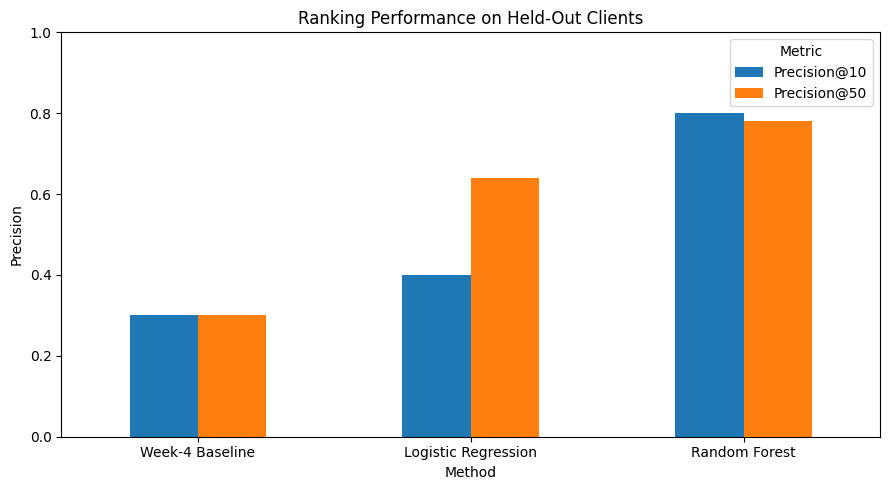

Saved figure:
work/figures/model_vs_baseline_precision.png


In [ ]:
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 1. Calculate model-vs-baseline results
# ---------------------------------------------------------

results = []

methods = {
    "Week-4 Baseline": baseline_scores,
    "Logistic Regression": logistic_scores,
    "Random Forest": random_forest_scores
}

for method_name, method_scores in methods.items():

    results.append(
        {
            "Method": method_name,
            "Precision@10": precision_at_k(
                y_test,
                method_scores,
                10
            ),
            "Precision@50": precision_at_k(
                y_test,
                method_scores,
                50
            )
        }
    )

model_results = pd.DataFrame(results)

model_results[
    ["Precision@10", "Precision@50"]
] = model_results[
    ["Precision@10", "Precision@50"]
].round(3)

print("MODEL VS BASELINE — GROUPED CLIENT HOLDOUT")
display(model_results)


# ---------------------------------------------------------
# 2. Plot model comparison
# ---------------------------------------------------------

figure_directory = "work/figures"

from pathlib import Path

Path(figure_directory).mkdir(
    parents=True,
    exist_ok=True
)

chart_data = (
    model_results
    .set_index("Method")
)

ax = chart_data.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title(
    "Ranking Performance on Held-Out Clients"
)

plt.ylabel("Precision")
plt.xlabel("Method")

plt.ylim(0, 1)

plt.xticks(
    rotation=0
)

plt.legend(
    title="Metric"
)

plt.tight_layout()

model_chart_path = (
    Path(figure_directory) /
    "model_vs_baseline_precision.png"
)

plt.savefig(
    model_chart_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved figure:")
print(model_chart_path)

## 5. Limitations


The Random Forest produced a stronger ranked review queue than the rule-based baseline on the measured grouped-client test set, but several limitations affect how this result should be interpreted.

### 1. The model uses an observed proxy, not a future outcome

The target is derived from whether `trend_direction == "down"`.

This represents an observed recent decline state rather than a future event. The model therefore should not be described as predicting which pages will decline in the future.

A more accurate interpretation is that the model ranks pages whose observable characteristics are associated with the measured decline proxy.

### 2. Some feature and target measurement periods may overlap

Features such as `impressions_90d`, `ctr` and `avg_position` describe recent search performance.

Because the decline proxy is also derived from recent performance, some of the information available to the model may overlap with the period used to define the target.

There is no direct label-derived feature in the final feature set, but this temporal overlap limits the strength of any future-prediction claim.

### 3. The model was trained on the 30,000-page modelling slice

The broader FlyRank warehouse was used to investigate data structure, availability and limitations, but the model results reported here come from the 30,000-page anonymised Refresh dataset.

The results should therefore not be presented as model performance measured across the complete warehouse release.

### 4. Validation design affects the measured result

Random page-level validation produced Precision@50 of 0.92, while the grouped client-level evaluation produced 0.78.

The random split contained pages from 31 clients on both sides of the split, while the grouped split contained zero shared clients.

This demonstrates that evaluation design materially affects the apparent performance. I therefore report the grouped-client result as the more relevant measurement for unseen-client generalisation.

However, this remains one grouped holdout and does not guarantee equivalent performance across every future client or content category.

### 5. High ranking scores still include errors

The Random Forest achieved Precision@50 of 0.78, meaning 39 of the top 50 recommendations matched the decline proxy while 11 did not.

These false positives matter because they could direct editorial attention toward pages that do not require intervention.

The system should therefore prioritise investigation rather than automatically trigger content changes.

### 6. Feature importance is not causality

Permutation importance identified `impressions_90d` and `avg_position` as the strongest measured contributors to the Random Forest ranking.

This does not establish that impressions or ranking position cause a page to decline. Feature importance describes how useful a variable was to this model on this dataset.

### 7. The model does not understand all editorial context

The available features do not fully capture factors such as:

* business value;
* content accuracy;
* search intent changes;
* seasonality;
* competitor activity;
* brand strategy;
* editorial quality;
* conversion value.

A high-priority recommendation can therefore still be inappropriate when a human considers information that is unavailable to the model.

### Honest interpretation

The strongest conclusion supported by this work is that, **on the measured grouped-client holdout, the Random Forest produced a more precise top-of-queue ranking for the observed decline proxy than the simple Week-4 baseline**.

The system should be treated as **directional decision-support for human content review**. It does not establish future decline, causality, or the effectiveness of any specific content intervention.


In [ ]:
# ---------------------------------------------------------
# Evidence supporting the limitations section
# ---------------------------------------------------------

limitations_evidence = pd.DataFrame(
    {
        "Limitation": [
            "Proxy target",
            "Modelling scope",
            "Validation sensitivity",
            "Grouped validation",
            "Top-50 errors",
            "Temporal overlap"
        ],
        "Measured evidence": [
            (
                "decline_proxy is derived from "
                "trend_direction == 'down'"
            ),
            (
                f"{len(page_dataset):,} pages used "
                "for model analysis"
            ),
            (
                "Random split P@50 = 0.92 vs "
                "grouped split P@50 = 0.78"
            ),
            (
                f"{len(shared_clients)} clients shared "
                "between grouped train/test"
            ),
            (
                "39 correct and 11 false positives "
                "in Random Forest Top 50"
            ),
            (
                "Recent search-performance features may "
                "overlap the decline-proxy measurement window"
            )
        ],
        "Implication": [
            "Do not claim clean future prediction.",
            "Do not claim model training on the full warehouse.",
            "Random page validation is more optimistic.",
            "Grouped holdout is the primary evaluation.",
            "Human review remains necessary.",
            "Interpret performance as observed decision-support."
        ]
    }
)

print("LIMITATIONS EVIDENCE")
display(limitations_evidence)

LIMITATIONS EVIDENCE


,Limitation,Measured evidence,Implication
0,Proxy target,decline_proxy is derived from trend_direction ...,Do not claim clean future prediction.
1,Modelling scope,"30,000 pages used for model analysis",Do not claim model training on the full wareho...
2,Validation sensitivity,Random split P@50 = 0.92 vs grouped split P@50...,Random page validation is more optimistic.
3,Grouped validation,0 clients shared between grouped train/test,Grouped holdout is the primary evaluation.
4,Top-50 errors,39 correct and 11 false positives in Random Fo...,Human review remains necessary.
5,Temporal overlap,Recent search-performance features may overlap...,Interpret performance as observed decision-sup...


## 6. Ranked recommendations


The final output is a ranked content-review queue designed to help an SEO specialist or content editor decide where to investigate first.

The validated Random Forest probability is used as the **priority score**. Higher-scoring pages appear earlier in the queue.

The model score itself does not prescribe an editorial change. Instead, transparent reason codes use observable page characteristics to suggest what the reviewer should investigate.

### Action playbook

#### 1. `HIGH_VISIBILITY_LOW_CTR` → `REVIEW_TITLE_AND_SNIPPET`

A page receives meaningful search visibility but has CTR below the median observed in the training data.

**Suggested review:** inspect the page title, search snippet, query intent and SERP context.

This does not mean the title is proven to be poor. Low CTR may also reflect query type, SERP features or other factors.

---

#### 2. `STRIKING_DISTANCE` → `REVIEW_CONTENT_EXPANSION`

A page has at least 300 impressions and an average search position between approximately 11 and 20.

**Suggested review:** investigate whether stronger topic coverage, intent alignment, internal linking or content depth could be appropriate.

The ranking position is a review signal rather than proof that expanding the page will improve its ranking.

---

#### 3. `STALE_VISIBLE` → `REVIEW_FOR_REFRESH`

A page has not been updated for at least 90 days but continues to receive meaningful search visibility.

**Suggested review:** check whether examples, statistics, links, product details or other information are outdated.

Earlier analysis found that staleness was a mixed signal, and it had relatively weak permutation importance in the final Random Forest. Therefore, age alone should never trigger a refresh.

---

#### 4. `HIGH_MODEL_SCORE` → `MANUAL_DIAGNOSTIC_REVIEW`

The model ranks the page highly, but it does not match one of the clearer review archetypes.

**Suggested review:** manually inspect the page, its search context and business importance before deciding whether any intervention is justified.

This fallback category is important because the Random Forest can identify combinations of signals that are not fully explained by a simple human-written rule.

### Human decision rule

For every recommendation, the final reviewer should be able to choose:

* `REFRESH`
* `TITLE_SNIPPET_REVIEW`
* `CONTENT_EXPANSION`
* `MONITOR`
* `NEEDS_MORE_INVESTIGATION`
* `NO_ACTION`

A high model score determines **review priority**, not the final action.

### Cost and value

The practical value of the system is reducing the number of pages that must be inspected manually. Editorial effort can be concentrated near the top of the queue instead of reviewing every page equally.

False positives still create a cost because they consume human review time and could lead to unnecessary edits. For this reason, the playbook prioritises investigation rather than automated intervention.

### What should not be automated

The system should not automatically rewrite, publish, delete, redirect or prune content. It should not automatically change titles or meta descriptions, and it should not claim that a recommended intervention will improve rankings, traffic or conversions.

The ranked recommendations are therefore **directional decision-support for human review**.


In [ ]:
# ---------------------------------------------------------
# 1. Create the held-out recommendation queue
# ---------------------------------------------------------

recommendation_queue = (
    model_data
    .iloc[test_indices]
    [
        [
            "content_id",
            "client_id",
            "days_since_last_update",
            "impressions_90d",
            "ctr",
            "avg_position",
            "search_volume",
            "decline_proxy"
        ]
    ]
    .copy()
)

# Random Forest probability = review-priority score
recommendation_queue["priority_score"] = (
    random_forest_scores
)


# ---------------------------------------------------------
# 2. Define transparent review thresholds
# ---------------------------------------------------------

minimum_visibility = 300

# Learn the CTR threshold from TRAINING DATA only
low_ctr_threshold = X_train["ctr"].median()

print(
    "Training-data median CTR:",
    round(low_ctr_threshold, 3)
)


# ---------------------------------------------------------
# 3. Convert page characteristics into review reasons
# ---------------------------------------------------------

def assign_recommendation(page):

    # High visibility but weaker-than-typical CTR
    if (
        page["impressions_90d"] >= minimum_visibility
        and page["ctr"] < low_ctr_threshold
    ):
        return pd.Series(
            [
                "HIGH_VISIBILITY_LOW_CTR",
                "REVIEW_TITLE_AND_SNIPPET"
            ]
        )

    # Visible page just outside stronger ranking territory
    if (
        page["impressions_90d"] >= minimum_visibility
        and pd.notna(page["avg_position"])
        and 10 < page["avg_position"] <= 20
    ):
        return pd.Series(
            [
                "STRIKING_DISTANCE",
                "REVIEW_CONTENT_EXPANSION"
            ]
        )

    # Older page that still has meaningful visibility
    if (
        page["days_since_last_update"] >= 90
        and page["impressions_90d"] >= minimum_visibility
    ):
        return pd.Series(
            [
                "STALE_VISIBLE",
                "REVIEW_FOR_REFRESH"
            ]
        )

    # High model score without one clear rule-based explanation
    return pd.Series(
        [
            "HIGH_MODEL_SCORE",
            "MANUAL_DIAGNOSTIC_REVIEW"
        ]
    )


recommendation_queue[
    ["reason_code", "suggested_review"]
] = recommendation_queue.apply(
    assign_recommendation,
    axis=1
)


# ---------------------------------------------------------
# 4. Rank highest priority first
# ---------------------------------------------------------

recommendation_queue = (
    recommendation_queue
    .sort_values(
        "priority_score",
        ascending=False
    )
    .reset_index(drop=True)
)

recommendation_queue.insert(
    0,
    "review_rank",
    range(1, len(recommendation_queue) + 1)
)


# ---------------------------------------------------------
# 5. Summarise recommended review types
# ---------------------------------------------------------

recommendation_summary = (
    recommendation_queue[
        ["reason_code", "suggested_review"]
    ]
    .value_counts()
    .reset_index(name="pages")
)

print("RECOMMENDATION ARCHETYPES")
display(recommendation_summary)


# ---------------------------------------------------------
# 6. Show the first 10 review priorities
# ---------------------------------------------------------

top_10_recommendations = (
    recommendation_queue
    .head(10)
    [
        [
            "review_rank",
            "content_id",
            "priority_score",
            "reason_code",
            "suggested_review",
            "days_since_last_update",
            "impressions_90d",
            "ctr",
            "avg_position"
        ]
    ]
)

print("\nTOP 10 HUMAN-REVIEW PRIORITIES")
display(top_10_recommendations)

Training-data median CTR: 0.08
RECOMMENDATION ARCHETYPES


,reason_code,suggested_review,pages
0,HIGH_MODEL_SCORE,MANUAL_DIAGNOSTIC_REVIEW,4176
1,HIGH_VISIBILITY_LOW_CTR,REVIEW_TITLE_AND_SNIPPET,977
2,STRIKING_DISTANCE,REVIEW_CONTENT_EXPANSION,668
3,STALE_VISIBLE,REVIEW_FOR_REFRESH,342



TOP 10 HUMAN-REVIEW PRIORITIES


,review_rank,content_id,priority_score,reason_code,suggested_review,days_since_last_update,impressions_90d,ctr,avg_position
0,1,content_26d48a980581,0.799401,HIGH_VISIBILITY_LOW_CTR,REVIEW_TITLE_AND_SNIPPET,106,1266,0.00,4.6
1,2,content_829c68e60d13,0.791887,HIGH_VISIBILITY_LOW_CTR,REVIEW_TITLE_AND_SNIPPET,106,307,0.00,4.9
2,3,content_f55fd2d8ed04,0.789607,STALE_VISIBLE,REVIEW_FOR_REFRESH,104,2237,0.09,1.3
3,4,content_64a482194d7a,0.786798,HIGH_VISIBILITY_LOW_CTR,REVIEW_TITLE_AND_SNIPPET,20,20971,0.06,35.8
4,5,content_50cd61b8e18d,0.785401,HIGH_VISIBILITY_LOW_CTR,REVIEW_TITLE_AND_SNIPPET,14,3799,0.05,19.1
5,6,content_e3ce3f8b5844,0.778650,STALE_VISIBLE,REVIEW_FOR_REFRESH,104,858,0.12,2.2
6,7,content_a138ab3bd14d,0.777664,HIGH_MODEL_SCORE,MANUAL_DIAGNOSTIC_REVIEW,104,200,0.00,1.9
7,8,content_c65ee459f729,0.776407,HIGH_VISIBILITY_LOW_CTR,REVIEW_TITLE_AND_SNIPPET,106,6526,0.00,17.4
8,9,content_b4c79208b569,0.775304,HIGH_VISIBILITY_LOW_CTR,REVIEW_TITLE_AND_SNIPPET,104,3245,0.06,1.9
9,10,content_9db40e41d57d,0.774637,HIGH_VISIBILITY_LOW_CTR,REVIEW_TITLE_AND_SNIPPET,20,2083,0.05,16.3


## 7. Artifacts the paper embeds


The deployed research page uses artifacts generated directly from this notebook so that the figures and headline numbers can be traced back to the analysis.

The final paper uses three main visual artifacts:

1. **Model vs baseline performance** — compares the Week-4 baseline, Logistic Regression and Random Forest on the same grouped-client holdout.
2. **Validation-design comparison** — shows the difference between random page-level validation and grouped client-level validation.
3. **Recommended-action distribution** — summarises the types of human review generated by the final action playbook.

The notebook also exports a metrics JSON containing the main numerical results used by the paper and a ranked action queue that can be regenerated from the validated model.

The queue contains pseudonymised identifiers and observable decision-support fields only. The evaluation proxy is excluded from the operational export.

These artifacts provide a reproducible bridge between the analysis notebook and the deployed research page.


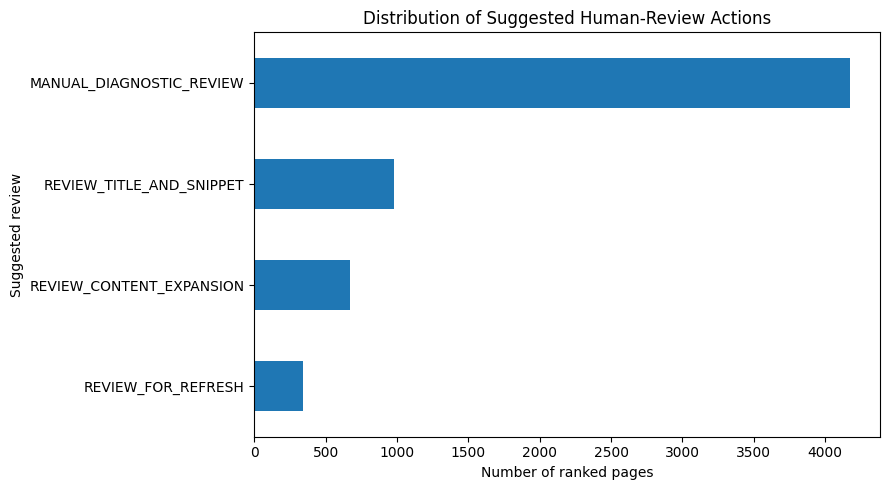

PERMUTATION IMPORTANCE


,feature,importance_mean,importance_std
0,impressions_90d,0.248,0.042143
1,avg_position,0.200,0.057271
2,ctr,0.078,0.056178
3,search_volume,0.048,0.051536
4,days_since_last_update,0.038,0.073457


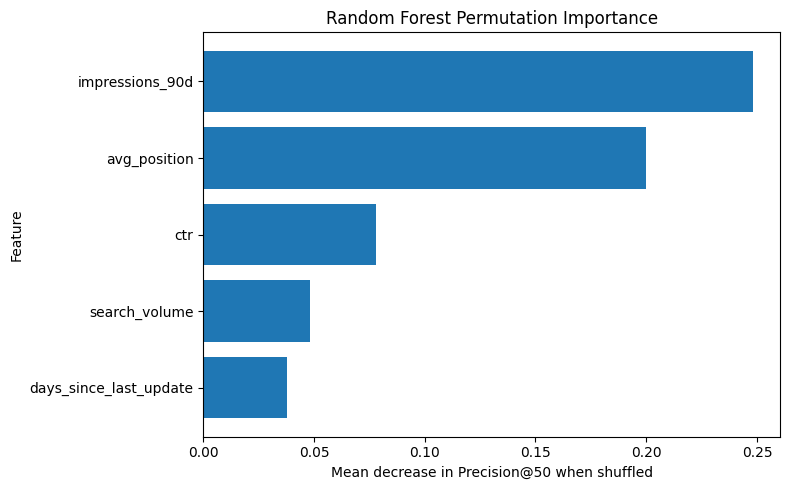

NameError: name 'y_test_random' is not defined

In [ ]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance


# ---------------------------------------------------------
# 1. Create artifact directories
# ---------------------------------------------------------

output_directory = Path("work/outputs")
figure_directory = Path("work/figures")

output_directory.mkdir(
    parents=True,
    exist_ok=True
)

figure_directory.mkdir(
    parents=True,
    exist_ok=True
)


# ---------------------------------------------------------
# 2. Export the operational ranked queue
# ---------------------------------------------------------

queue_export_columns = [
    "review_rank",
    "content_id",
    "client_id",
    "priority_score",
    "reason_code",
    "suggested_review",
    "days_since_last_update",
    "impressions_90d",
    "ctr",
    "avg_position",
    "search_volume"
]

paper_action_queue = (
    recommendation_queue[
        queue_export_columns
    ]
    .copy()
)

queue_output_path = (
    output_directory /
    "action_playbook_queue.csv"
)

paper_action_queue.to_csv(
    queue_output_path,
    index=False
)


# ---------------------------------------------------------
# 3. Generate action-distribution figure
# ---------------------------------------------------------

action_distribution = (
    recommendation_queue["suggested_review"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))

action_distribution.plot(
    kind="barh"
)

plt.title(
    "Distribution of Suggested Human-Review Actions"
)

plt.xlabel("Number of ranked pages")
plt.ylabel("Suggested review")

plt.tight_layout()

action_chart_path = (
    figure_directory /
    "action_distribution.png"
)

plt.savefig(
    action_chart_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# 4. Recalculate permutation importance
#    for a reproducible feature-importance receipt
# ---------------------------------------------------------

def precision_at_50_scorer(
    model,
    features,
    target
):
    probability_scores = (
        model.predict_proba(features)[:, 1]
    )

    return precision_at_k(
        target,
        probability_scores,
        50
    )


permutation_results = permutation_importance(
    random_forest_model,
    X_test,
    y_test,
    scoring=precision_at_50_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

feature_importance = pd.DataFrame(
    {
        "feature": model_features,
        "importance_mean":
            permutation_results.importances_mean,
        "importance_std":
            permutation_results.importances_std
    }
)

feature_importance = (
    feature_importance
    .sort_values(
        "importance_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

print("PERMUTATION IMPORTANCE")
display(feature_importance)


# ---------------------------------------------------------
# 5. Create feature-importance figure
# ---------------------------------------------------------

feature_chart_data = (
    feature_importance
    .sort_values(
        "importance_mean",
        ascending=True
    )
)

plt.figure(figsize=(8, 5))

plt.barh(
    feature_chart_data["feature"],
    feature_chart_data["importance_mean"]
)

plt.title(
    "Random Forest Permutation Importance"
)

plt.xlabel(
    "Mean decrease in Precision@50 when shuffled"
)

plt.ylabel("Feature")

plt.tight_layout()

feature_chart_path = (
    figure_directory /
    "feature_importance.png"
)

plt.savefig(
    feature_chart_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# 6. Build a traceable metrics receipt
# ---------------------------------------------------------

capstone_metrics = {
    "research_lane":
        "Refresh / Content Opportunity Scoring",

    "warehouse_daily_rows":
        78835655,

    "modelling_pages":
        int(len(page_dataset)),

    "modelling_clients":
        int(
            page_dataset["client_id"].nunique()
        ),

    "validation_design":
        "Grouped client holdout",

    "training_pages":
        int(len(X_train)),

    "test_pages":
        int(len(X_test)),

    "shared_clients":
        int(len(shared_clients)),

    "test_base_rate":
        round(
            float(y_test.mean()),
            3
        ),

    "week_4_baseline": {
        "precision_at_10":
            round(
                float(
                    precision_at_k(
                        y_test,
                        baseline_scores,
                        10
                    )
                ),
                3
            ),

        "precision_at_50":
            round(
                float(
                    precision_at_k(
                        y_test,
                        baseline_scores,
                        50
                    )
                ),
                3
            )
    },

    "logistic_regression": {
        "precision_at_10":
            round(
                float(
                    precision_at_k(
                        y_test,
                        logistic_scores,
                        10
                    )
                ),
                3
            ),

        "precision_at_50":
            round(
                float(
                    precision_at_k(
                        y_test,
                        logistic_scores,
                        50
                    )
                ),
                3
            )
    },

    "random_forest": {
        "precision_at_10":
            round(
                float(
                    precision_at_k(
                        y_test,
                        random_forest_scores,
                        10
                    )
                ),
                3
            ),

        "precision_at_50":
            round(
                float(
                    precision_at_k(
                        y_test,
                        random_forest_scores,
                        50
                    )
                ),
                3
            )
    },

    "random_page_split": {
        "precision_at_10":
            round(
                float(
                    precision_at_k(
                        y_test_random,
                        random_split_scores,
                        10
                    )
                ),
                3
            ),

        "precision_at_50":
            round(
                float(
                    precision_at_k(
                        y_test_random,
                        random_split_scores,
                        50
                    )
                ),
                3
            )
    },

    "feature_importance": {
        row["feature"]: {
            "mean": round(
                float(row["importance_mean"]),
                3
            ),
            "std": round(
                float(row["importance_std"]),
                3
            )
        }
        for _, row in feature_importance.iterrows()
    },

    "interpretation": (
        "Observed decision-support performance "
        "on a grouped client holdout. "
        "The target is an observed decline proxy; "
        "results do not establish future decline "
        "or causal intervention impact."
    )
}


# ---------------------------------------------------------
# 7. Export metrics JSON
# ---------------------------------------------------------

metrics_output_path = (
    output_directory /
    "capstone_metrics.json"
)

with open(
    metrics_output_path,
    "w",
    encoding="utf-8"
) as metrics_file:

    json.dump(
        capstone_metrics,
        metrics_file,
        indent=2
    )


# ---------------------------------------------------------
# 8. Create artifact manifest
# ---------------------------------------------------------

artifact_manifest = pd.DataFrame(
    {
        "Artifact": [
            "Model comparison chart",
            "Validation comparison chart",
            "Action distribution chart",
            "Feature importance chart",
            "Metrics receipt",
            "Ranked action queue"
        ],

        "Path": [
            "work/figures/model_vs_baseline_precision.png",
            "work/figures/validation_design_comparison.png",
            str(action_chart_path),
            str(feature_chart_path),
            str(metrics_output_path),
            str(queue_output_path)
        ],

        "Paper use": [
            "Results",
            "Results / validation",
            "Ranked recommendations",
            "Results / interpretation",
            "Numerical claim traceability",
            "Action-playbook evidence"
        ]
    }
)

print("\nFINAL PAPER ARTIFACTS")
display(artifact_manifest)

print("\nMetrics receipt:")
print(
    json.dumps(
        capstone_metrics,
        indent=2
    )
)

print(
    "\nCapstone artifacts generated successfully."
)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## 8. Tell the Story

### 5-minute demo outline

#### 1. Question

FlyRank-style content teams may manage thousands of pages but have limited time to investigate refresh and optimisation opportunities.

My research question was:

**Can observable page-level search-performance and freshness signals rank content pages for human review more effectively than a simple rule-based baseline?**

#### 2. Method

I used a 30,000-page anonymised modelling dataset covering 32 pseudonymised clients.

I compared:

* a transparent stale-and-visible baseline;
* Logistic Regression;
* Random Forest.

The final evaluation used a grouped client holdout so that clients in the test set were not seen during training.

#### 3. One chart

Show the **Model vs Baseline Precision** chart.

Key results:

* Baseline Precision@10: 0.30
* Logistic Regression Precision@10: 0.40
* Random Forest Precision@10: 0.80
* Baseline Precision@50: 0.30
* Logistic Regression Precision@50: 0.64
* Random Forest Precision@50: 0.78

#### 4. One honest result

A random page split produced Random Forest Precision@50 of 0.92, but 31 clients appeared in both training and testing.

Under the grouped client split, there were zero shared clients and Precision@50 was 0.78.

I therefore report **0.78** as the more defensible result for unseen-client evaluation.

The target is also an observed decline proxy rather than a clean future outcome, so the system is presented as decision-support rather than a future-decline predictor.

#### 5. One recommendation

One example action is:

**HIGH_VISIBILITY_LOW_CTR → REVIEW_TITLE_AND_SNIPPET**

This means a page has meaningful search visibility but relatively weak CTR, so a human reviewer should inspect the title, snippet, query intent and SERP context.

The recommendation does not prove that the title is poor or that changing it will improve performance.

### Social post

I built a machine-learning content opportunity scoring system during my FlyRank AI Internship to answer a practical SEO question: **which pages should a content team investigate first?**

I compared a transparent rule-based baseline with Logistic Regression and Random Forest using a 30,000-page anonymised modelling dataset and grouped client validation. Random Forest produced the strongest measured ranking at **0.80 Precision@10 and 0.78 Precision@50**, compared with 0.30/0.30 for the baseline.

One of my biggest takeaways was that validation design matters as much as model choice. A random page split produced 0.92 Precision@50, but the more defensible unseen-client evaluation produced 0.78. I turned the final scores into a human-reviewed action playbook with transparent reason codes rather than automated content decisions.

### Employer-facing summary

I built an end-to-end machine-learning decision-support system that ranks content pages for SEO and editorial review, progressing from data auditing and a transparent baseline through Logistic Regression, Random Forest, grouped validation, leakage checks and an action playbook.

The modelling used a 30,000-page anonymised slice from the wider FlyRank internship data release, with client-level holdout validation to test performance on unseen clients.

The final Random Forest achieved measured Precision@10 of 0.80 and Precision@50 of 0.78 versus 0.30/0.30 for the baseline, while remaining explicitly framed as human decision-support rather than automatic content optimisation.
